In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scipy.ndimage import uniform_filter1d
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup
from tqdm.notebook import tqdm
import scipy.signal as sp

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [4]:
patch_fs_c14 = 50023.8986874656




In [5]:
patch_c14 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c14patch_filt.npy'
#get cell number 
cell_num = 'c14'


#get patch data 
patch_filt_c14 = np.load(patch_c14)
patch_c14_one_ms = float(patch_fs_c14  / 1000)
patch_times_c14 = np.arange(0, np.shape(patch_filt_c14 )[0]) / patch_c14_one_ms # in ms instead of sec


patch_channel = -patch_filt_c14


# IAP to inferred EAP

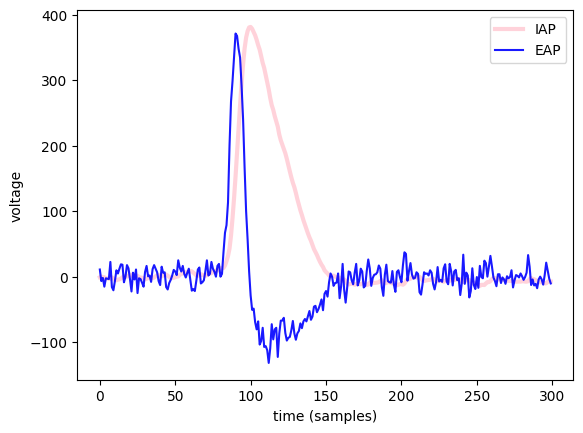

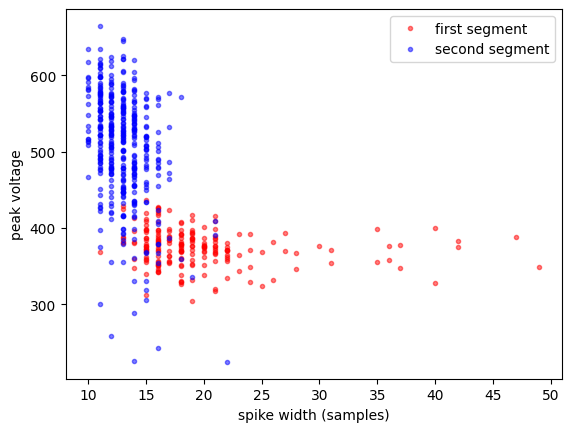

In [6]:


patch_fs = patch_fs_c14

# smooth the iap a bit, otherwise it's WAY more noisy
patch_filt = uniform_filter1d(patch_channel, size=10)

iap2eap = np.diff(patch_filt)
iap2eap = iap2eap * 10 # this is arbitrary, just to scale it better to the iap

first_segment = iap2eap[:3000000]
last_segment = iap2eap[51000000:54000000]


# show that the pseudo-eap works
plt.plot(patch_filt[21900:22200], 'pink', linewidth=3, alpha=0.7, label='IAP')
plt.plot(first_segment[21900:22200], 'b', alpha = 0.9, label='EAP')
plt.xlabel('time (samples)')
plt.ylabel('voltage')
plt.legend()
plt.show()




# function to get peaks, then get the minimum after the peak to get peak-trough duration, which is a proxy for spike-width
def find_next_minima(iap, eap, peakheight, minwin):
    peaks, peak_height = find_peaks(iap, height=peakheight, distance=minwin)
    
    # Using list comprehension to find the index of the next minimum for each peak
    next_minima_indices = [
        peak + np.argmin(eap[peak:peak + minwin]) if np.any(eap[peak:] < eap[peak]) else None
        for peak in peaks
    ]
    
    peak_height = peak_height['peak_heights']
    return peaks, next_minima_indices, peak_height

peaks_first, troughs_first, amp_first = find_next_minima(first_segment, first_segment, 200, 50)
peaks_last, troughs_last, amp_last = find_next_minima(last_segment, last_segment, 200, 50)

# plot the 2d feature space of peak voltage vs. spike width
plt.plot(troughs_first-peaks_first, amp_first, 'r.', alpha=0.5, label='first segment')
plt.plot(troughs_last-peaks_last, amp_last, 'b.', alpha=0.5, label='second segment')
plt.xlabel('spike width (samples)')
plt.ylabel('peak voltage')
plt.legend()
plt.show()

### Check how the inferred EAPs compare to the actual EAPs

In [7]:
#load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/c14npx_filt.npy'
npx_fs = 30000 # sampling rate
npx_one_ms = float(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109

In [8]:
# open and load the data
npx_filt = np.load(npx_path)

npx_times = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec"""

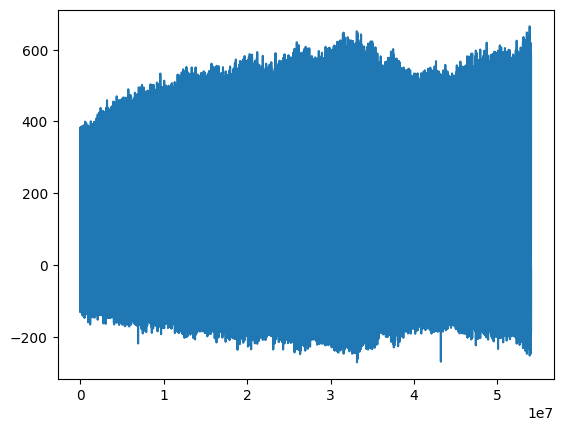

In [9]:
plt.plot(iap2eap)

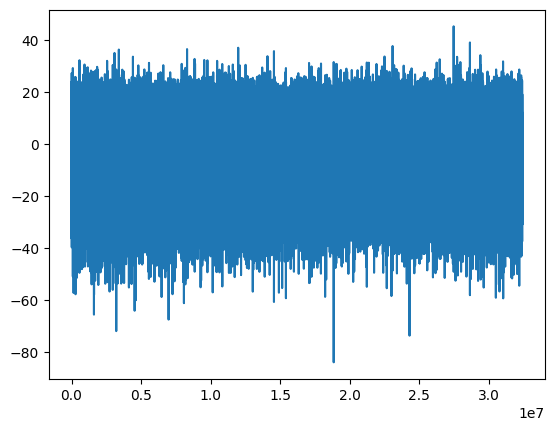

In [10]:
plt.plot(npx_filt)

In [11]:
#Run spikeparam on real EAPs 
sp_ex = Spike(thresh_amp=20, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/1746 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


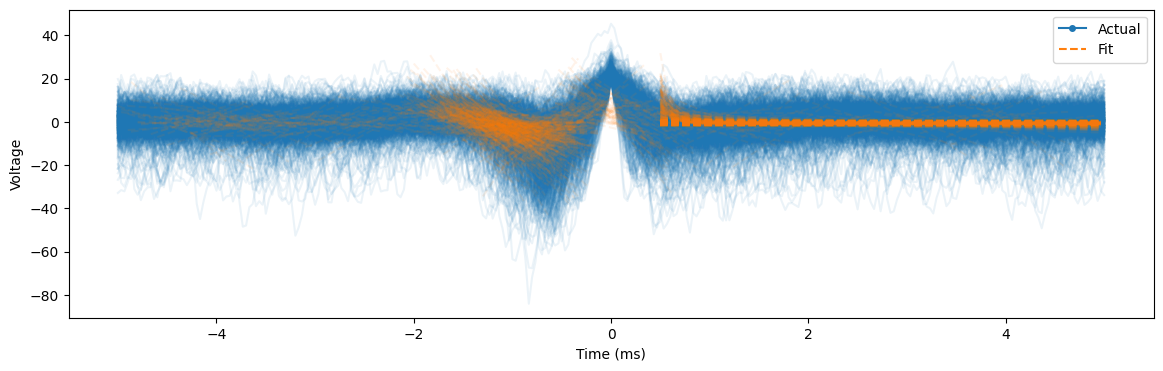

In [12]:
sp_ex.plot()

In [13]:
#Downsample inferred EAPs to match real EAP sampling rate
iap2eap = sp.resample(iap2eap, int((len(iap2eap)/patch_fs)*npx_fs))

In [30]:
#Rescale inferred EAPs so that it matches real EAPs 
iap2eap = iap2eap/ 10 # this is arbitrary, just to scale it better to the iap

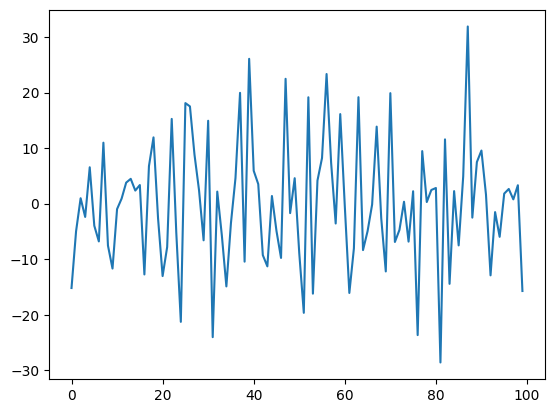

In [28]:
plt.plot(iap2eap[0:100])

In [32]:
#Run spikeparam on inferred EAPs 

sp_ex_inf = Spike(thresh_amp=20, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp_ex_inf.fit(iap2eap, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/3568 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


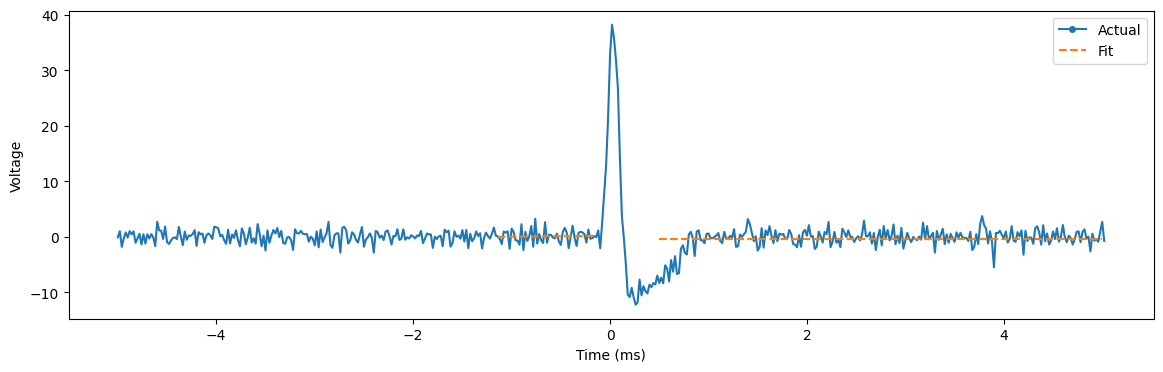

In [33]:
sp_ex_inf.plot(10
)

#### Temporally align real EAPs and inferred EAPs, only inferred ones that align with the real EAPs

In [34]:
sp_ex_inf_inds = sp_ex_inf.spike_inds
sp_ex_inds = sp_ex.spike_inds

sp_ex_inf_inds_ms = patch_times_c14[sp_ex_inf.spike_inds]
sp_ex_inds_ms = npx_times[sp_ex.spike_inds]

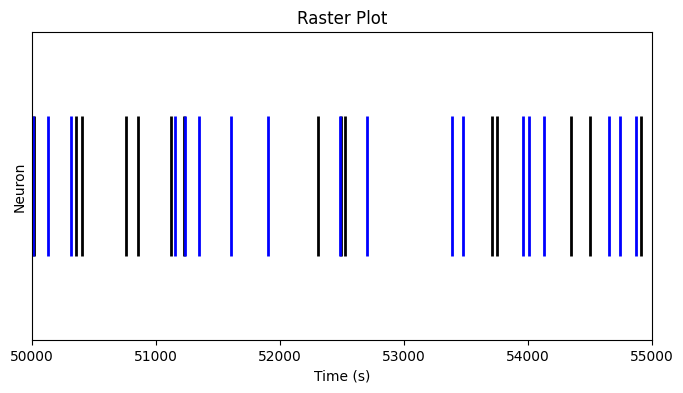

In [35]:
# Plotting the raster plot
plt.figure(figsize=(8, 4))
plt.eventplot(sp_ex_inds_ms, color='black', linewidths=2)
plt.eventplot(sp_ex_inf_inds_ms, color='blue', linewidths=2)
plt.xlabel('Time (s)')
plt.xlim(50000, 55000)
plt.ylabel('Neuron')
plt.title('Raster Plot')
plt.yticks([])  # Disable y-axis ticks as this is a raster plot
plt.show()

#### Calculate coincident and extraneous spikes between real IAPs and real EAPs

In [36]:
#Run spikeparam on IAPs 

sp = Spike(thresh_amp=400, window_length=(5., 5.), smooth_frac=.01)

#sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
 #      param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/3968 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


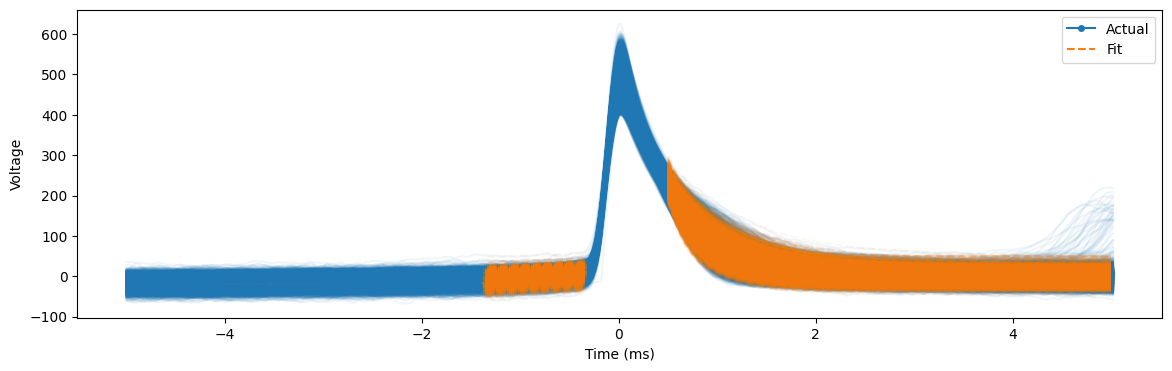

In [37]:
sp.plot()

In [38]:
sp_inds = sp.spike_inds


sp_inds_ms = patch_times_c14[sp.spike_inds]


In [52]:
coincidence_window = 1  # milliseconds
# Lists to store the coincident spike times
coincident_eap_spikes = []
coincident_iap_spikes = []


#Initialize counters
coincident_count = 0
non_coincident_eap_count = 0
non_coincident_iap_count = 0

# Iterate through each EAP spike time
for eap_spike_time in sp_ex_inds_ms:
    coincident_found = False
    # Search for coincident IAP spikes within the time window
    for iap_spike_time in sp_inds_ms:
        if abs(eap_spike_time - iap_spike_time) <= coincidence_window:
            coincident_count += 1
            coincident_found = True
            coincident_eap_spikes.append(eap_spike_time)  # Save coincident EAP spike time
            coincident_iap_spikes.append(iap_spike_time)  # Save coincident IAP spike time
            break  # Exit the loop once a coincident spike is found
    # If no coincident IAP spike is found, increment the non-coincident EAP count
    if not coincident_found:
        non_coincident_eap_count += 1

# Calculate the number of non-coincident IAP spikes
non_coincident_iap_count = len(sp_inds_ms) - coincident_count

# Print the results
print(f"Number of coincident spikes: {coincident_count}")
print(f"Number of non-coincident EAP spikes: {non_coincident_eap_count}")
print(f"Number of non-coincident IAP spikes: {non_coincident_iap_count}")

Number of coincident spikes: 268
Number of non-coincident EAP spikes: 1478
Number of non-coincident IAP spikes: 3700


#### Plot coincident spikes

In [ ]:


import matplotlib.pyplot as plt

# Define a function to plot coincident spikes
def plot_coincident_spikes(eap_spikes, iap_spikes, patch_filt, npx_filt, iap2eap, patch_fs, npx_fs, iap2eap_fs, pre_window_ms=5, post_window_ms=4):
    fig, axs = plt.subplots(len(eap_spikes), 3, figsize=(15, len(eap_spikes) * 2))  # Updated to 3 columns for inferred EAP
    
    # Convert pre and post window length from ms to indices
    eap_pre_window_len = int(pre_window_ms * (npx_fs / 1000))  # Pre-window length for EAP data
    eap_post_window_len = int(post_window_ms * (npx_fs / 1000))  # Post-window length for EAP data
    iap_pre_window_len = int(pre_window_ms * (patch_fs / 1000))  # Pre-window length for IAP data
    iap_post_window_len = int(post_window_ms * (patch_fs / 1000))  # Post-window length for IAP data
    
    for i, (eap_spike_idx, iap_spike_idx) in enumerate(zip(eap_spikes, iap_spikes)):
        # Convert spike times to indices
        print(f"Original EAP Spike Time {i+1}: {eap_spike_idx} ms")
        print(f"Original IAP Spike Time {i+1}: {iap_spike_idx} ms")
        
        # Convert to index based on the sampling rates
        eap_spike_idx = int(eap_spike_idx * (npx_fs / 1000))  # Convert from ms to indices
        iap_spike_idx = int(iap_spike_idx * (patch_fs / 1000))  # Convert from ms to indices
        print(f"Converted EAP Spike Index {i+1}: {eap_spike_idx}")
        print(f"Converted IAP Spike Index {i+1}: {iap_spike_idx}")
        
        # Plot the corresponding EAP data from npx_filt
        eap_window_start = eap_spike_idx - eap_pre_window_len
        eap_window_end = eap_spike_idx + eap_post_window_len
        
        # Check bounds and print details
        if eap_window_start >= 0 and eap_window_end < len(npx_filt):
            eap_slice = npx_filt[eap_window_start:eap_window_end]
            print(f"EAP Slice (Spike {i+1}): {eap_slice[:5]}...")  # Print the first few values to check if it's valid
            
            if len(eap_slice) > 0 and not all(v == 0 for v in eap_slice):  # Ensure slice is not empty or flat
                axs[i, 0].plot(eap_slice)
                axs[i, 0].set_title(f'EAP Coincident Spike {i+1}')
                axs[i, 0].set_xlabel('Time (ms)')
                axs[i, 0].set_ylabel('Amplitude')
            else:
                axs[i, 0].set_title(f'EAP Spike {i+1} Empty or Flat Data')
        else:
            axs[i, 0].set_title(f'EAP Spike {i+1} Out of Bounds')

        # Plot the corresponding IAP data from patch_filt
        iap_window_start = iap_spike_idx - iap_pre_window_len
        iap_window_end = iap_spike_idx + iap_post_window_len
        
        # Check bounds and print details
        if iap_window_start >= 0 and iap_window_end < len(patch_filt):
            iap_slice = patch_filt[iap_window_start:iap_window_end]
            print(f"IAP Slice (Spike {i+1}): {iap_slice[:5]}...")  # Print the first few values to check if it's valid
            
            if len(iap_slice) > 0 and not all(v == 0 for v in iap_slice):  # Ensure slice is not empty or flat
                axs[i, 1].plot(iap_slice)
                axs[i, 1].set_title(f'IAP Coincident Spike {i+1}')
                axs[i, 1].set_xlabel('Time (ms)')
                axs[i, 1].set_ylabel('Amplitude')
            else:
                axs[i, 1].set_title(f'IAP Spike {i+1} Empty or Flat Data')
        else:
            axs[i, 1].set_title(f'IAP Spike {i+1} Out of Bounds')

        # Convert IAP spike indices to `iap2eap` sampling rate
        iap2eap_spike_idx = int(iap_spike_idx * (iap2eap_fs / patch_fs))

        # Calculate window start and end based on the `iap2eap` sampling rate
        iap2eap_window_start = iap2eap_spike_idx - eap_pre_window_len
        iap2eap_window_end = iap2eap_spike_idx + eap_post_window_len
        
        # Check bounds and print details
        if iap2eap_window_start >= 0 and iap2eap_window_end < len(iap2eap):
            iap2eap_slice = iap2eap[iap2eap_window_start:iap2eap_window_end]
            print(f"IAP2EAP Slice (Spike {i+1}): {iap2eap_slice[:5]}...")  # Print the first few values to check if it's valid
            
            if len(iap2eap_slice) > 0 and not all(v == 0 for v in iap2eap_slice):  # Ensure slice is not empty or flat
                axs[i, 2].plot(iap2eap_slice)
                axs[i, 2].set_title(f'IAP2EAP Spike {i+1}')
                axs[i, 2].set_xlabel('Time (ms)')
                axs[i, 2].set_ylabel('Amplitude')
            else:
                axs[i, 2].set_title(f'IAP2EAP Spike {i+1} Empty or Flat Data')
        else:
            axs[i, 2].set_title(f'IAP2EAP Spike {i+1} Out of Bounds')

    plt.tight_layout()
    plt.show()

# Now, use the function to plot coincident spikes
# Convert spike times to indices using the sampling rates and plot them with a 10 ms window (5 ms before, 4 ms after)
coincident_iap_spikes = [i * (patch_fs / 1000) for i in coincident_iap_spikes]
coincident_eap_spikes = [i * (npx_fs / 1000) for i in coincident_eap_spikes]

plot_coincident_spikes(coincident_eap_spikes, coincident_iap_spikes, patch_filt, npx_filt, iap2eap, patch_fs, npx_fs, npx_fs)


# EAP to inferred IAP